Discussion

In [9]:
# import data
import pandas as pd
import numpy as np

# Load data files
file_data_path='MY Stock Market 2000-01-03 .csv'

# Read data file
with open(file_data_path,'r') as f:
    data_content=f.readlines()

missing_values=['n/a','na','--','?']

df=pd.read_csv(file_data_path)

df.replace(missing_values,np.nan,inplace=True)

df.head()

,Unnamed: 0,Date,Ticker,Company_Name,Open,High,Low,Close,Adj Close,Volume
0,0,2002-08-13,3A.KL,THREE-A RESOURCES BHD,0.110,0.110,0.110,0.110,0.078549,0.0
1,1,2002-08-14,3A.KL,THREE-A RESOURCES BHD,0.108,0.108,0.108,0.108,0.077121,3165250.0
2,2,2002-08-15,3A.KL,THREE-A RESOURCES BHD,0.112,0.112,0.112,0.112,0.079977,1940250.0
3,3,2002-08-16,3A.KL,THREE-A RESOURCES BHD,0.110,0.110,0.110,0.110,0.078549,1231250.0
4,4,2002-08-19,3A.KL,THREE-A RESOURCES BHD,0.108,0.108,0.108,0.108,0.077121,2106500.0


In [10]:
df.isnull().sum()

Unnamed: 0          0
Date                0
Ticker              0
Company_Name        0
Open            85759
High            85759
Low             85759
Close           85759
Adj Close       85759
Volume          85759
dtype: int64

In [11]:
# Replace 'n/a','na','--','?' with Nan
df.dropna(inplace=True)
df.isnull().sum()

Unnamed: 0      0
Date            0
Ticker          0
Company_Name    0
Open            0
High            0
Low             0
Close           0
Adj Close       0
Volume          0
dtype: int64

In [12]:
# Group Name: HappyGoLucky
# Member 1: CHIA JIUN YUAN
# Member 2: BEH SONG YOU
# Member 3: LAU SHE HONG
# Member 4: HIEW CHENG HAN

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Discussion

numeric_columns=['Open','High','Low','Close','Adj Close','Volume']
eda=pd.DataFrame({
    'Mean':df[numeric_columns].mean(),
    'Sum':df[numeric_columns].sum(),
    'Min':df[numeric_columns].min(),
    'Max':df[numeric_columns].max(),
    'Range':df[numeric_columns].max()-df[numeric_columns].min(),
    'Median':df[numeric_columns].median(),
    'Std Dev':df[numeric_columns].std(),
    'Skewness':df[numeric_columns].skew(),
    'Kurtosis':df[numeric_columns].kurt(),
    '25th Percentile':df[numeric_columns].quantile(0.25),
    '75th Percentile':df[numeric_columns].quantile(0.75)
}).T

# Display EDA Statistics
print(eda)

                          Open           High            Low          Close  \
Mean                  1.774666       1.797188       1.753387       1.776414   
Sum              821052.772311  831472.486592  811207.900075  821861.391719   
Min                   0.002933       0.002933       0.002933       0.002933   
Max                 525.000000     547.500000     475.000000     477.500000   
Range               524.997067     547.497067     474.997067     477.497067   
Median                0.666666       0.677272       0.656666       0.670000   
Std Dev               8.127995       8.218818       8.009219       8.101338   
Skewness             34.857845      34.725244      34.850572      34.733650   
Kurtosis           1641.680868    1628.987252    1644.766176    1631.973251   
25th Percentile       0.306665       0.315000       0.300000       0.309998   
75th Percentile       1.539998       1.558329       1.518180       1.540000   

                     Adj Close        Volume  
Mean

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

Question 1: What are the important trends in stock prices in Bursa Malaysia over the past two decades?

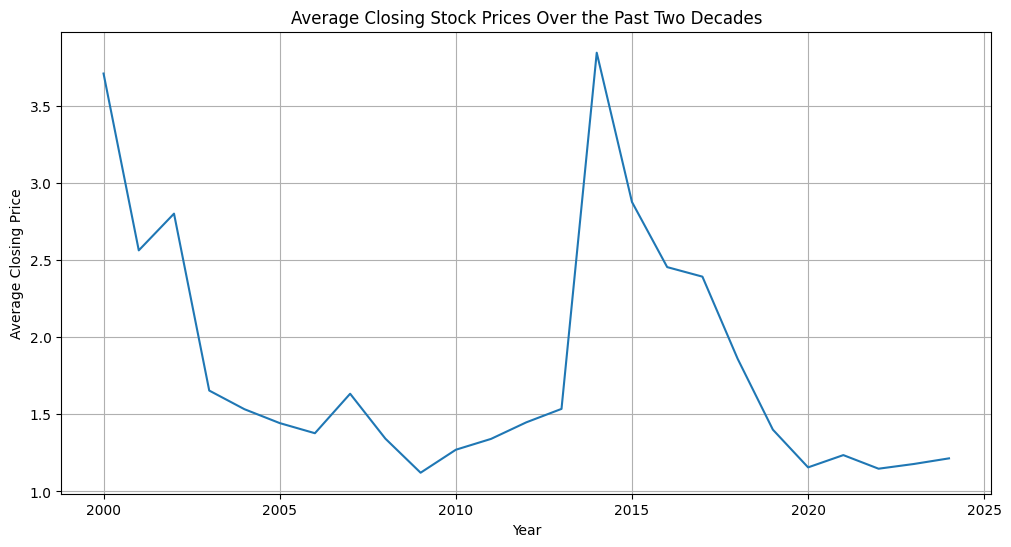

In [14]:
plt.figure(figsize=(12,6))
df.groupby(df['Date'].dt.year)['Close'].mean().plot()
plt.title('Average Closing Stock Prices Over the Past Two Decades')
plt.xlabel('Year')
plt.ylabel('Average Closing Price')
plt.grid(True)
plt.show()

Question 2: What were the highest volatility industries or companies in stock prices and what caused it?

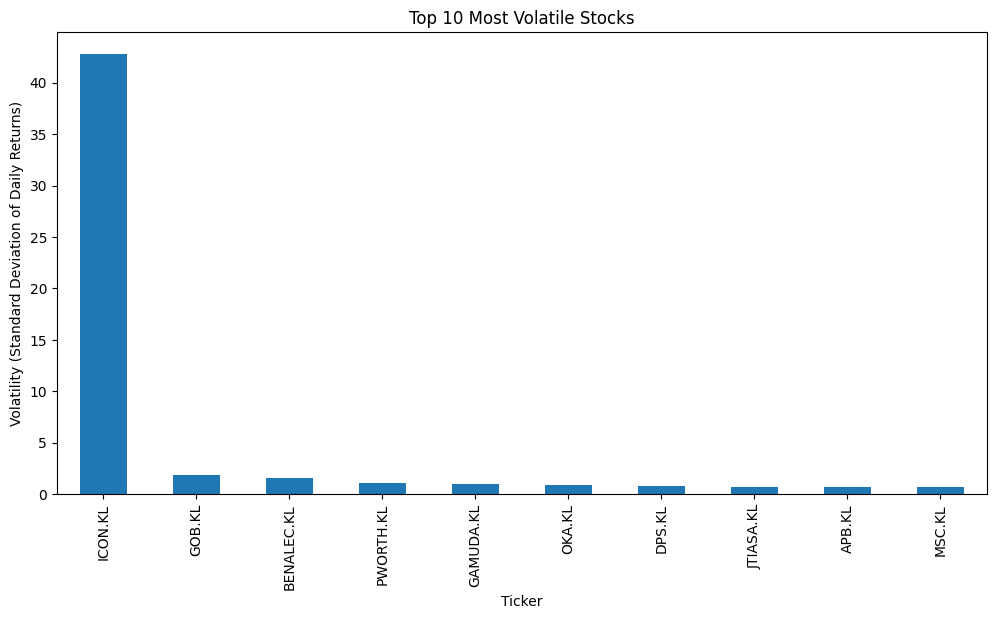

In [15]:
df['Daily Return']=df['Close'].pct_change()
volatility=df.groupby('Ticker')['Daily Return'].std().sort_values(ascending=False)

plt.figure(figsize=(12,6))
volatility.head(10).plot(kind='bar')
plt.title('Top 10 Most Volatile Stocks')
plt.xlabel('Ticker')
plt.ylabel('Volatility (Standard Deviation of Daily Returns)')
plt.show()

Question 3: Does trading volume possess a positive correlation with the stock price movement for top-performing stocks based in Bursa Malaysia?

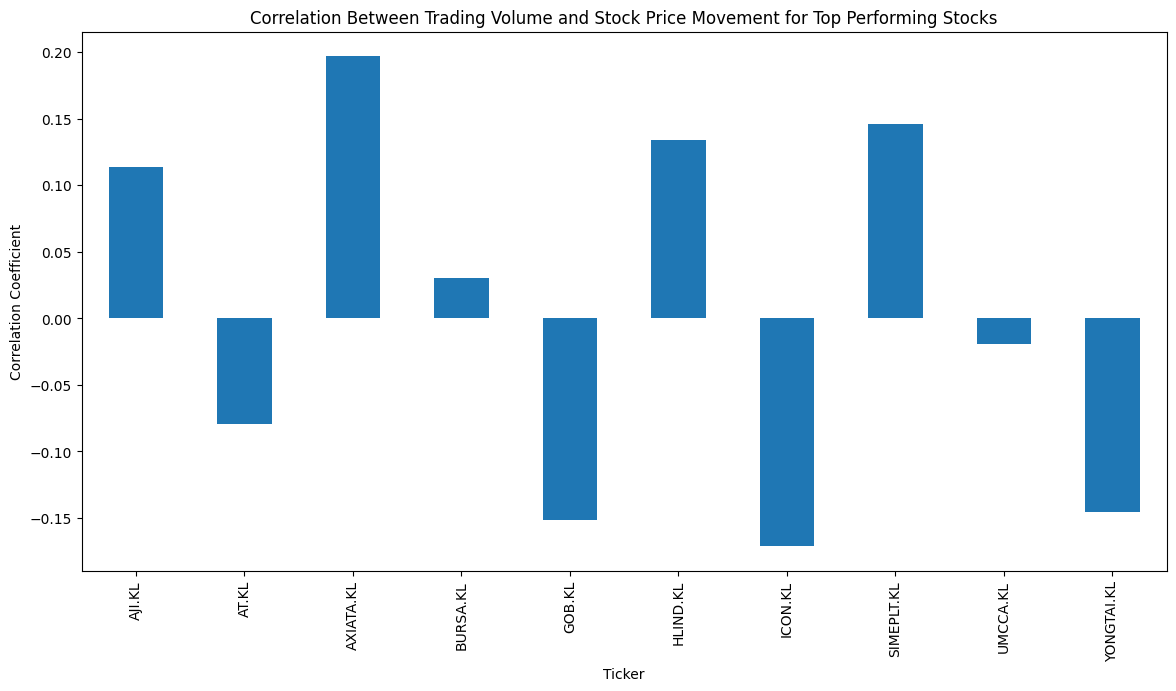

In [16]:
top_performing_stocks=df.groupby('Ticker')['Close'].mean().sort_values(ascending=False).head(10).index

# Filter data for top performing stocks
top_stocks_df=df[df['Ticker'].isin(top_performing_stocks)]

# Calculate correlation between trading volume and stock price movement
correlation_matrix = top_stocks_df.groupby('Ticker')[['Volume','Close']].corr().unstack().iloc[:, 1]

# Plot correlation
plt.figure(figsize=(14, 7))
correlation_matrix.plot(kind='bar')
plt.title('Correlation Between Trading Volume and Stock Price Movement for Top Performing Stocks')
plt.xlabel('Ticker')
plt.ylabel('Correlation Coefficient')
plt.show()

Question 4: What are the fastest-growing stocks and the returns of the stock?

The line plot below shows the daily returns of the stock.
- The stock exhibits periods of high volatility, with significant spikes and dips in daily returns.

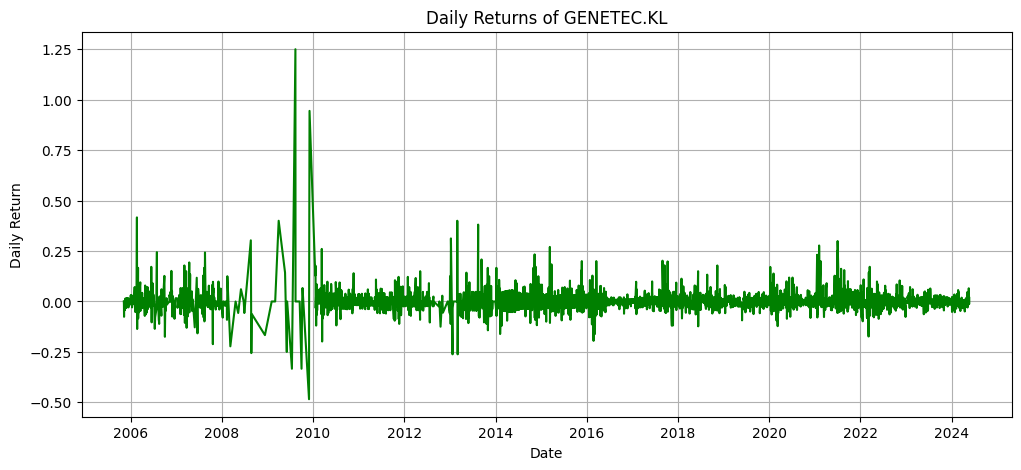

In [17]:
stock_ticker = "GENETEC.KL"
df_stock = df[df["Ticker"] == stock_ticker].sort_values("Date")

# Daily Returns
df_stock["Daily_Return"] = df_stock["Close"].pct_change()
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_stock, x="Date", y="Daily_Return", color="green")
plt.title("Daily Returns of {}".format(stock_ticker))
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.grid(True)
plt.show()

The cumulative return plot shows the overall performance of the stock over time.
- The stock started with a very small growth from 2005 - 2020, but it gotten a surge in growth during and after the Covid Pandemic

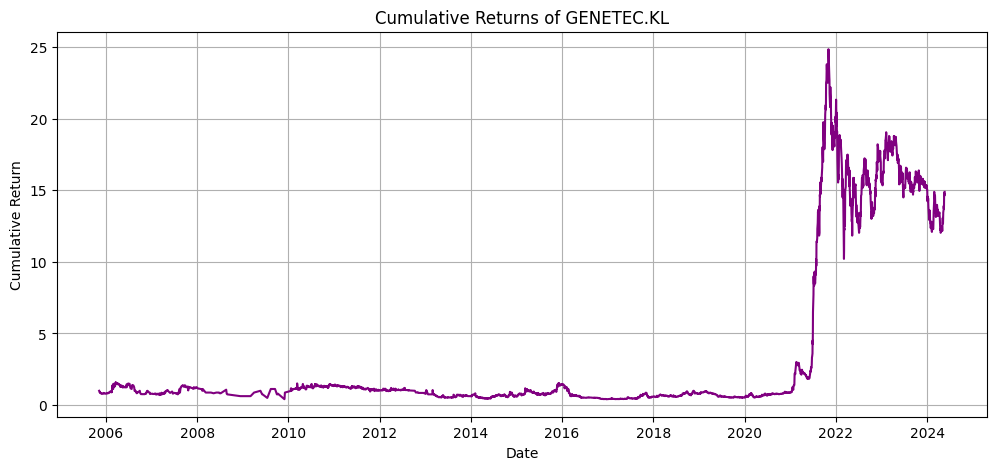

In [18]:
# Cumulative Returns
df_stock["Cumulative_Return"] = (1 + df_stock["Daily_Return"]).cumprod()
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_stock, x="Date", y="Cumulative_Return", color="purple")
plt.title("Cumulative Returns of {}".format(stock_ticker))
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.show()